In [1]:
import numpy as np
import networkx as nx

from sklearn.linear_model import LinearRegression

In [2]:
#-------------------------EX1-------------------------------------

path = "ca-AstroPh.txt"  

G = nx.Graph()

with open(path, "r") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        u_str, v_str = line.split()
        u, v = int(u_str), int(v_str)

        if G.has_edge(u, v):
            G[u][v]["weight"] += 1
        else:
            G.add_edge(u, v, weight=1)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())


Nodes: 18772
Edges: 198110


In [3]:
def principal_eigenvalue_weighted(ego: nx.Graph) -> float:
    
    A = nx.to_numpy_array(ego, weight="weight", dtype=float)
    if A.size == 0:
        return 0.0
    evals, _ = np.linalg.eigh(A)
    return float(evals.max()) if evals.size else 0.0


Ni_dict = {}
Ei_dict = {}
Wi_dict = {}
lambda_dict = {}

for n in G.nodes():
    Ni = G.degree(n)

    ego = nx.ego_graph(G, n, radius=1, center=False)

    Ei = ego.number_of_edges()
    Wi = sum(data.get("weight", 1) for _, _, data in ego.edges(data=True))
    lam = principal_eigenvalue_weighted(ego)

    Ni_dict[n] = Ni
    Ei_dict[n] = Ei
    Wi_dict[n] = Wi
    lambda_dict[n] = lam

nx.set_node_attributes(G, Ni_dict, "Ni")
nx.set_node_attributes(G, Ei_dict, "Ei")
nx.set_node_attributes(G, Wi_dict, "Wi")
nx.set_node_attributes(G, lambda_dict, "lambda_w")

some_node = next(iter(G.nodes()))
print(some_node, G.nodes[some_node])


84424 {'Ni': 75, 'Ei': 211, 'Wi': 421, 'lambda_w': 17.714715499361596}


In [4]:
nodes = list(G.nodes())
Ni = np.array([G.nodes[n]["Ni"] for n in nodes], dtype=float)
Ei = np.array([G.nodes[n]["Ei"] for n in nodes], dtype=float)

mask = (Ni > 0) & (Ei > 0)
X = np.log(Ni[mask]).reshape(-1, 1)
Y = np.log(Ei[mask])

lr = LinearRegression()
lr.fit(X, Y)

theta = float(lr.coef_[0])
logC = float(lr.intercept_)
C = float(np.exp(logC))

print("Fitted power-law: Ei ≈ C * Ni^theta")
print("C =", C)
print("theta =", theta)


Fitted power-law: Ei ≈ C * Ni^theta
C = 0.3629653137515927
theta = 1.8352254885785833


In [5]:
eps = 1e-12

scores = {}

for n in nodes:
    x_i = float(G.nodes[n]["Ni"])
    y_i = float(G.nodes[n]["Ei"])

    y_hat = C * (x_i ** theta) if x_i > 0 else 0.0

    a = max(y_i, y_hat, eps)
    b = max(min(y_i, y_hat), eps)

    score = (a / b) * np.log(abs(y_i - y_hat) + 1.0)
    scores[n] = float(score)

nx.set_node_attributes(G, scores, "score_Ei_Ni")

top_k = 20
top = sorted(scores.items(), key=lambda kv: kv[1], reverse=True)[:top_k]
top


[(72074, 23077613741570.977),
 (80866, 7979421108218.122),
 (129462, 7979421108218.122),
 (71754, 7979421108218.122),
 (12073, 3585146070188.1743),
 (79011, 3585146070188.1743),
 (115740, 3585146070188.1743),
 (5677, 3585146070188.1743),
 (84198, 3585146070188.1743),
 (83298, 3585146070188.1743),
 (28327, 3585146070188.1743),
 (9281, 3585146070188.1743),
 (62642, 3585146070188.1743),
 (17500, 3585146070188.1743),
 (129969, 3585146070188.1743),
 (70981, 1076020668434.9584),
 (54192, 1076020668434.9584),
 (118119, 1076020668434.9584),
 (69937, 1076020668434.9584),
 (107784, 1076020668434.9584)]

In [6]:
for n, s in top:
    print(f"node={n:>6}  score={s:>10.4f}  Ni={G.nodes[n]['Ni']:>6}  Ei={G.nodes[n]['Ei']:>6}")

node= 72074  score=23077613741570.9766  Ni=     6  Ei=     0
node= 80866  score=7979421108218.1221  Ni=     4  Ei=     0
node=129462  score=7979421108218.1221  Ni=     4  Ei=     0
node= 71754  score=7979421108218.1221  Ni=     4  Ei=     0
node= 12073  score=3585146070188.1743  Ni=     3  Ei=     0
node= 79011  score=3585146070188.1743  Ni=     3  Ei=     0
node=115740  score=3585146070188.1743  Ni=     3  Ei=     0
node=  5677  score=3585146070188.1743  Ni=     3  Ei=     0
node= 84198  score=3585146070188.1743  Ni=     3  Ei=     0
node= 83298  score=3585146070188.1743  Ni=     3  Ei=     0
node= 28327  score=3585146070188.1743  Ni=     3  Ei=     0
node=  9281  score=3585146070188.1743  Ni=     3  Ei=     0
node= 62642  score=3585146070188.1743  Ni=     3  Ei=     0
node= 17500  score=3585146070188.1743  Ni=     3  Ei=     0
node=129969  score=3585146070188.1743  Ni=     3  Ei=     0
node= 70981  score=1076020668434.9584  Ni=     2  Ei=     0
node= 54192  score=1076020668434.9584  

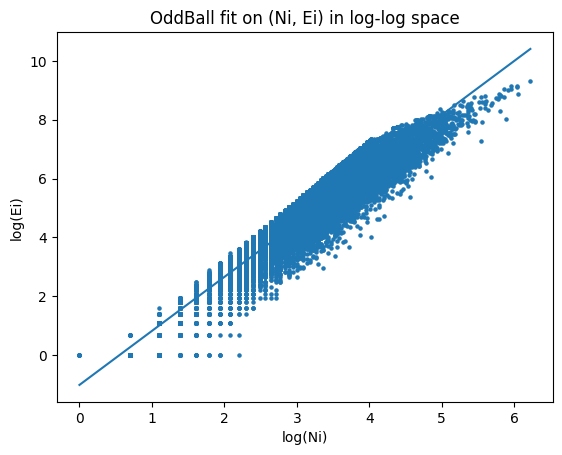

In [7]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(np.log(Ni[mask]), np.log(Ei[mask]), s=5)
xline = np.linspace(np.log(Ni[mask]).min(), np.log(Ni[mask]).max(), 200)
yline = logC + theta * xline
plt.plot(xline, yline)

plt.xlabel("log(Ni)")
plt.ylabel("log(Ei)")
plt.title("OddBall fit on (Ni, Ei) in log-log space")
plt.show()


In [8]:
#----------------------------------EX2-------------------------------------

import random
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

G_reg = nx.random_regular_graph(d=3, n=100)

G_cave = nx.connected_caveman_graph(l=10, k=20)

nx.set_edge_attributes(G_reg, 1, "weight")
nx.set_edge_attributes(G_cave, 1, "weight")

G = nx.union(G_reg, G_cave, rename=("R_", "C_"))

def connect_components_randomly(G, max_tries=100000):
    comps = [list(c) for c in nx.connected_components(G)]
    tries = 0
    while len(comps) > 1:
        tries += 1
        if tries > max_tries:
            raise RuntimeError("Could not connect components within max_tries. Increase max_tries.")

        c1 = comps[0]
        c2 = comps[1]
        u = random.choice(c1)
        v = random.choice(c2)

        if not G.has_edge(u, v):
            G.add_edge(u, v, weight=1)

        comps = [list(c) for c in nx.connected_components(G)]
    return G

G = connect_components_randomly(G)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Connected:", nx.is_connected(G))


Nodes: 300
Edges: 2051
Connected: True


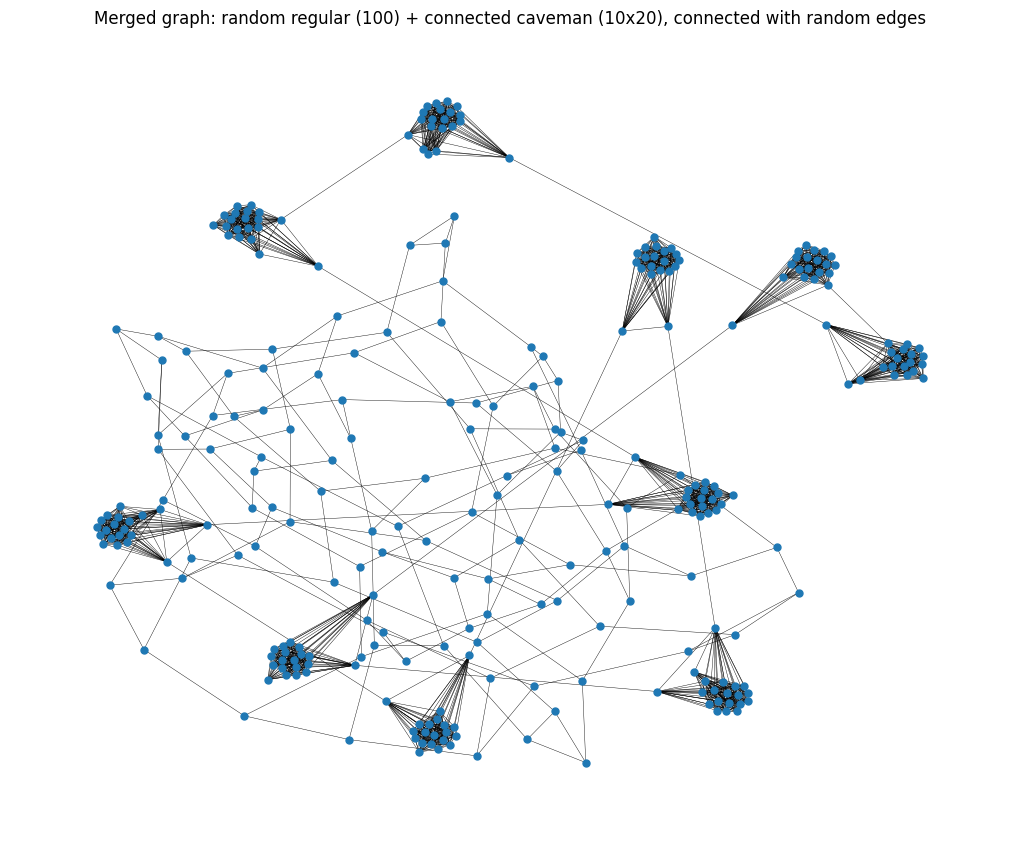

In [10]:
pos = nx.spring_layout(G, seed=42, k=0.18)  

plt.figure(figsize=(10, 8))
nx.draw(G, pos, node_size=25, width=0.3)
plt.title("Merged graph: random regular (100) + connected caveman (10x20), connected with random edges")
plt.show()

In [11]:
from sklearn.linear_model import LinearRegression

def principal_eigenvalue_weighted(ego: nx.Graph) -> float:
    A = nx.to_numpy_array(ego, weight="weight", dtype=float)
    if A.size == 0:
        return 0.0
    evals, _ = np.linalg.eigh(A)  
    return float(evals.max()) if evals.size else 0.0

Ni_dict, Ei_dict, Wi_dict, lambda_dict = {}, {}, {}, {}

for n in G.nodes():
    Ni = G.degree(n)
    ego = nx.ego_graph(G, n, radius=1, center=False)  

    Ei = ego.number_of_edges()
    Wi = sum(data.get("weight", 1) for _, _, data in ego.edges(data=True))
    lam = principal_eigenvalue_weighted(ego)

    Ni_dict[n] = Ni
    Ei_dict[n] = Ei
    Wi_dict[n] = Wi
    lambda_dict[n] = lam

nx.set_node_attributes(G, Ni_dict, "Ni")
nx.set_node_attributes(G, Ei_dict, "Ei")
nx.set_node_attributes(G, Wi_dict, "Wi")
nx.set_node_attributes(G, lambda_dict, "lambda_w")

nodes = list(G.nodes())
Ni = np.array([G.nodes[n]["Ni"] for n in nodes], dtype=float)
Ei = np.array([G.nodes[n]["Ei"] for n in nodes], dtype=float)

mask = (Ni > 0) & (Ei > 0)
X = np.log(Ni[mask]).reshape(-1, 1)
Y = np.log(Ei[mask])

lr = LinearRegression()
lr.fit(X, Y)

theta = float(lr.coef_[0])
logC = float(lr.intercept_)
C = float(np.exp(logC))

print(f"Power-law fit: Ei ≈ {C:.4f} * Ni^{theta:.4f}")


Power-law fit: Ei ≈ 0.0478 * Ni^2.7730


In [12]:
eps = 1e-12
scores = {}
yhat = {}

for n in nodes:
    x_i = float(G.nodes[n]["Ni"])
    y_i = float(G.nodes[n]["Ei"])

    pred = C * (x_i ** theta) if x_i > 0 else 0.0
    yhat[n] = pred

    a = max(y_i, pred, eps)
    b = max(min(y_i, pred), eps)

    score = (a / b) * np.log(abs(y_i - pred) + 1.0)
    scores[n] = float(score)

nx.set_node_attributes(G, scores, "score_Ei_Ni")


In [13]:
clique_candidates = [n for n in nodes if G.nodes[n]["Ei"] > yhat[n]]

top10_clique_nodes = sorted(clique_candidates, key=lambda n: G.nodes[n]["score_Ei_Ni"], reverse=True)[:10]

print("Top 10 clique-suspect nodes:")
for n in top10_clique_nodes:
    print(f"{n:>6}  score={G.nodes[n]['score_Ei_Ni']:.4f}  Ni={G.nodes[n]['Ni']}  Ei={G.nodes[n]['Ei']}  pred={yhat[n]:.2f}")


Top 10 clique-suspect nodes:
   C_1  score=2.3567  Ni=18  Ei=153  pred=144.71
  C_21  score=2.3567  Ni=18  Ei=153  pred=144.71
  C_41  score=2.3567  Ni=18  Ei=153  pred=144.71
  C_61  score=2.3567  Ni=18  Ei=153  pred=144.71
  C_81  score=2.3567  Ni=18  Ei=153  pred=144.71
 C_101  score=2.3567  Ni=18  Ei=153  pred=144.71
 C_121  score=2.3567  Ni=18  Ei=153  pred=144.71
 C_141  score=2.3567  Ni=18  Ei=153  pred=144.71
 C_161  score=2.3567  Ni=18  Ei=153  pred=144.71
 C_181  score=2.3567  Ni=18  Ei=153  pred=144.71


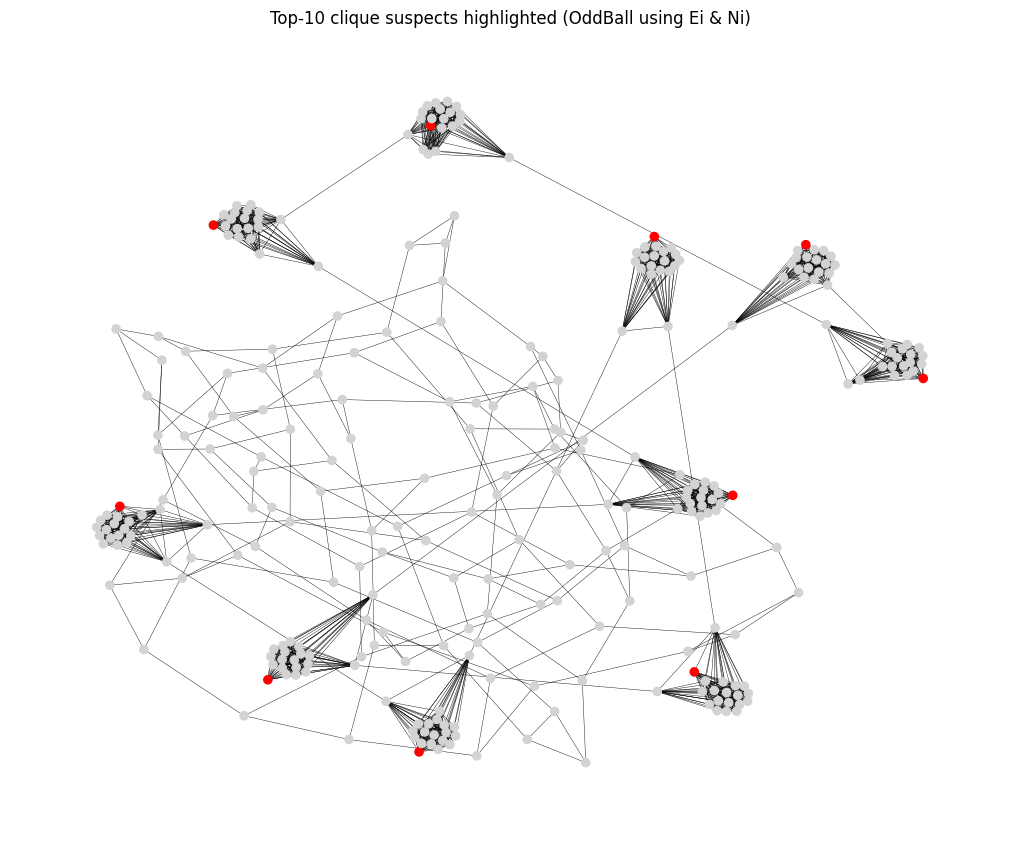

In [14]:
highlight = set(top10_clique_nodes)
node_colors = ["red" if n in highlight else "lightgray" for n in G.nodes()]

plt.figure(figsize=(10, 8))
nx.draw(G, pos, node_color=node_colors, node_size=35, width=0.3)
plt.title("Top-10 clique suspects highlighted (OddBall using Ei & Ni)")
plt.show()


In [15]:
print("How many of top10 are from clique-side (C_*)?",
      sum(1 for n in top10_clique_nodes if str(n).startswith("C_")),
      "/ 10")

How many of top10 are from clique-side (C_*)? 10 / 10


In [17]:
import torch
print(torch.__version__)

2.9.0+cpu


In [18]:
!pip install torch-geometric

   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 1.3/1.3 MB 10.8 MB/s  0:00:00

   --- ------------------------------------  1/11 [tqdm]
   --- ------------------------------------  1/11 [tqdm]
   --- ------------------------------------  1/11 [tqdm]
   --- ------------------------------------  1/11 [tqdm]
   --- ------------------------------------  1/11 [tqdm]
   --- ------------------------------------  1/11 [tqdm]
   ---------- -----------------------------  3/11 [multidict]
   --------------------- ------------------  6/11 [aiohappyeyeballs]
   ------------------------- --------------  7/11 [yarl]
   ----------------------------- ----------  8/11 [aiosignal]
   -------------------------------- -------  9/11 [aiohttp]
   -------------------------------- -------  9/11 [aiohttp]
   -------------------------------- -------  9/11 [aiohttp]
   -------------------------------- -------  9/11 [aiohttp]
   ---------------------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from torch_geometric.nn import GCNConv
print("GCNConv imported successfully")

GCNConv imported successfully


In [2]:
#----------------------------------EX3-------------------------------------

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from scipy.io import loadmat
from sklearn.metrics import roc_auc_score

from torch_geometric.nn import GCNConv
from torch_geometric.utils.convert import from_scipy_sparse_matrix

In [3]:
mat_path = "ACM.mat"  

data = loadmat(mat_path)

X_sp = data["Attributes"]  
A_sp = data["Network"]     
y = data["Label"]        

y = np.array(y).reshape(-1)

try:
    X_np = X_sp.toarray().astype(np.float32)
except AttributeError:
    X_np = np.array(X_sp, dtype=np.float32)

X = torch.tensor(X_np, dtype=torch.float32)

edge_index, edge_weight = from_scipy_sparse_matrix(A_sp)

A_dense = torch.tensor(A_sp.toarray(), dtype=torch.float32)

N, F_in = X.shape
print("N nodes:", N)
print("F attributes:", F_in)
print("edge_index:", edge_index.shape)
print("A_dense:", A_dense.shape)
print("labels:", y.shape, "unique:", np.unique(y))


N nodes: 16484
F attributes: 8337
edge_index: torch.Size([2, 164350])
A_dense: torch.Size([16484, 16484])
labels: (16484,) unique: [0 1]


In [4]:
class Encoder(nn.Module):
    def __init__(self, in_channels, hidden1=128, hidden2=64):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden1)
        self.conv2 = GCNConv(hidden1, hidden2)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        return x  # Z


class AttributeDecoder(nn.Module):
    def __init__(self, out_channels, hidden1=128, hidden2=64):
        super().__init__()
        self.conv1 = GCNConv(hidden2, hidden1)
        self.conv2 = GCNConv(hidden1, out_channels)

    def forward(self, z, edge_index):
        x_hat = self.conv1(z, edge_index)
        x_hat = F.relu(x_hat)
        x_hat = self.conv2(x_hat, edge_index)
        x_hat = F.relu(x_hat)  
        return x_hat


class StructureDecoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.conv = GCNConv(latent_dim, latent_dim)

    def forward(self, z, edge_index):
        z2 = self.conv(z, edge_index)
        z2 = F.relu(z2)
        A_hat = z2 @ z2.t()   # NxN
        return A_hat


class GraphAutoencoder(nn.Module):
    def __init__(self, in_channels, hidden1=128, latent_dim=64):
        super().__init__()
        self.encoder = Encoder(in_channels, hidden1=hidden1, hidden2=latent_dim)
        self.attr_decoder = AttributeDecoder(in_channels, hidden1=hidden1, hidden2=latent_dim)
        self.struct_decoder = StructureDecoder(latent_dim=latent_dim)

    def forward(self, x, edge_index):
        z = self.encoder(x, edge_index)
        x_hat = self.attr_decoder(z, edge_index)
        A_hat = self.struct_decoder(z, edge_index)
        return x_hat, A_hat, z


In [5]:
def gae_loss(X, X_hat, A, A_hat, alpha=0.8):
    attr_term = torch.norm(X - X_hat, p="fro") ** 2
    struct_term = torch.norm(A - A_hat, p="fro") ** 2
    return alpha * attr_term + (1.0 - alpha) * struct_term

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

alpha = 0.8
lr = 0.004
epochs = 5  

model = GraphAutoencoder(in_channels=F_in, hidden1=128, latent_dim=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

X_d = X.to(device)
A_d = A_dense.to(device)
edge_index_d = edge_index.to(device)

y_np = y.astype(int)  

for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    X_hat, A_hat, Z = model(X_d, edge_index_d)
    loss = gae_loss(X_d, X_hat, A_d, A_hat, alpha=alpha)

    loss.backward()
    optimizer.step()

    if epoch % 5 == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            X_hat, A_hat, _ = model(X_d, edge_index_d)

            attr_err = torch.sum((X_d - X_hat) ** 2, dim=1)  

            struct_err = torch.sum((A_d - A_hat) ** 2, dim=1) 

            scores = (alpha * attr_err + (1 - alpha) * struct_err).detach().cpu().numpy()

        try:
            auc = roc_auc_score(y_np, scores)
        except ValueError as e:
            auc = None
            print("ROC AUC error:", e)

        if auc is not None:
            print(f"Epoch {epoch:3d} | Loss: {loss.item():.4e} | ROC AUC: {auc:.4f}")
        else:
            print(f"Epoch {epoch:3d} | Loss: {loss.item():.4e}")


Device: cpu
Epoch   1 | Loss: 3.9769e+04 | ROC AUC: 0.7579


KeyboardInterrupt: 

In [9]:
model.eval()
with torch.no_grad():
    X_hat, A_hat, _ = model(X_d, edge_index_d)
    attr_err = torch.sum((X_d - X_hat) ** 2, dim=1)
    struct_err = torch.sum((A_d - A_hat) ** 2, dim=1)
    scores = (alpha * attr_err + (1 - alpha) * struct_err).detach().cpu().numpy()

top_k = 20
top_idx = np.argsort(scores)[::-1][:top_k]
print("Top anomalies (node id, score, label):")
for i in top_idx:
    print(i, scores[i], y_np[i])

Top anomalies (node id, score, label):
5418 101.51327 0
13934 38.831158 0
8500 36.807365 0
97 33.980984 0
3737 32.006607 0
5985 31.397911 0
16195 30.388378 0
7278 30.220577 0
7892 28.535988 0
12647 27.035362 0
10186 24.178175 0
4105 24.094852 1
2930 23.452412 0
15476 23.11888 0
8266 22.301243 0
21 21.10065 0
5299 20.830912 0
9605 20.434147 0
13389 19.784885 1
129 19.703884 0
